<a href="https://colab.research.google.com/github/JenniferShearer/ENDG-511-Project-Repo/blob/project_nathan/project_nathan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import datasets

In [2]:
#upload kaggle.json
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nathansawatzky","key":"703072937f56fc86b08c5c9e6f0bb134"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [9]:
!pip install kagglehub

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ollioctopus/asl-dataset")

print("Path to dataset files:", path)

100%|██████████| 741M/741M [00:08<00:00, 94.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/4


In [5]:
import subprocess
import sys
from pathlib import Path
import json
from dataclasses import dataclass
import math
from typing import Optional
from tqdm.auto import tqdm
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
import h5py
from timm.utils import accuracy
from timm.layers import trunc_normal_
import matplotlib.pyplot as plt
import os
import random
from PIL import Image
from glob import glob
from sklearn.model_selection import train_test_split
import shutil
import pandas as pd
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model
import tensorflow as tf
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import os

print("Root:", path)
print("Level 1:", os.listdir(path))

for item in os.listdir(path):
    sub = os.path.join(path, item)
    if os.path.isdir(sub):
        print(f"\n{sub}:")
        print(os.listdir(sub)[:10])

Root: /root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/4
Level 1: ['with_profile_1', 'with_profile', 'with_profile_Jenny_1', 'data']

/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/4/with_profile_1:
['with_profile_1']

/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/4/with_profile:
['with_profile']

/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/4/with_profile_Jenny_1:
['with_profile_Jenny_1']

/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/4/data:
['data']


In [8]:
dataset_path = os.path.join(path, "data", "data")
output_path = path + "/dataset_split"

valid_ext = (".jpg", ".jpeg", ".png")

image_paths = []
labels = []

# collect full dataset and labels
for label in os.listdir(dataset_path):
    label_path = os.path.join(dataset_path, label)

    if not os.path.isdir(label_path):
        continue

    for f in os.listdir(label_path):
        if f.lower().endswith(valid_ext):
            full_path = os.path.join(label_path, f)
            image_paths.append(full_path)
            labels.append(label)

# Train/Test split -> random 42 to reporduce it
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

# make function to copy paths into folders
def copy_to_split(paths, labels, split_name):
    for src_path, label in zip(paths, labels):
        dest_dir = os.path.join(output_path, split_name, label)
        os.makedirs(dest_dir, exist_ok=True)

        filename = os.path.basename(src_path)
        dest_path = os.path.join(dest_dir, filename)

        shutil.copy2(src_path, dest_path)

# copy into class folders
copy_to_split(train_paths, train_labels, "train")
copy_to_split(test_paths, test_labels, "test")

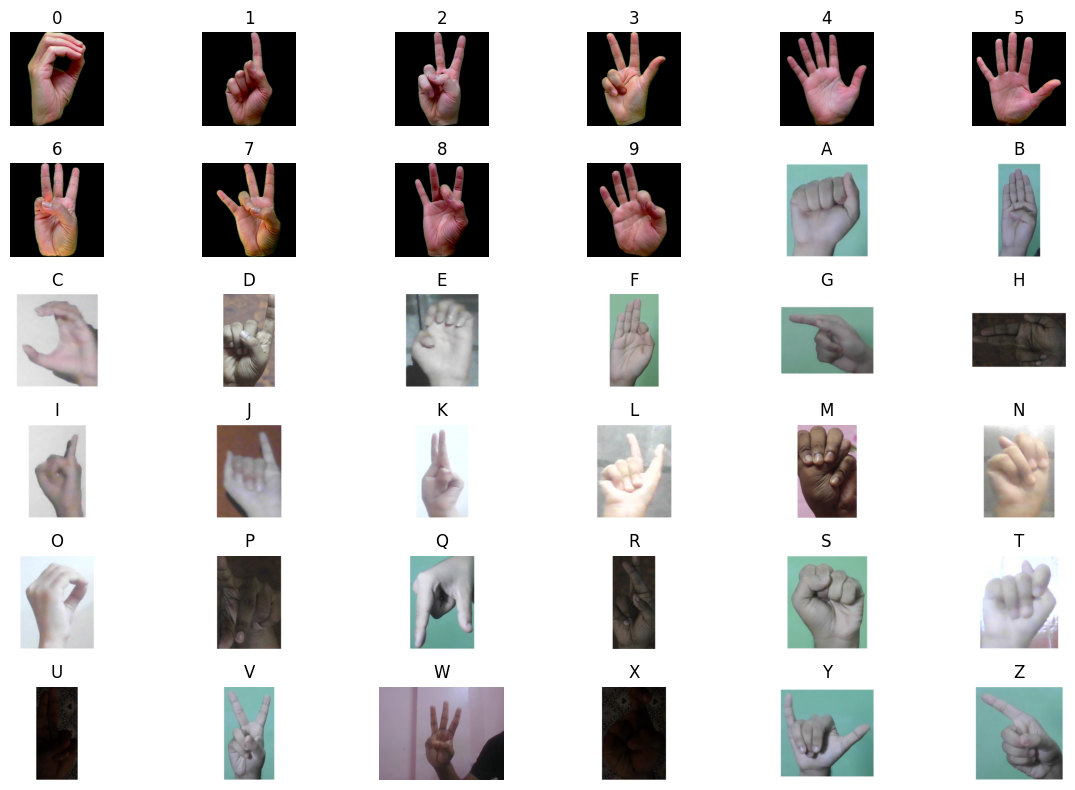

In [9]:


# Paths
train_path = path + "/dataset_split/train"
val_path   = path + "/dataset_split/val"

# Settings
img_height = 224
img_width = 224
batch_size = 32
seed = 42

# Load datasets from folders
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    seed=seed
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(class_names)
print("Num classes:", num_classes)

# Normalization
normalization = layers.Rescaling(1./255)

# Data augmentation for TRAINING ONLY
data_augmentation = keras.Sequential([
    layers.RandomRotation(factor=20/180, fill_mode='nearest'),   # about ±20 degrees
    layers.RandomZoom(height_factor=0.10, width_factor=0.10),
    layers.RandomTranslation(height_factor=0.10, width_factor=0.10, fill_mode='nearest'),
    layers.RandomContrast(factor=0.15),
], name="asl_augmentation")

# Optional brightness augmentation
def add_brightness(images, labels):
    images = tf.image.random_brightness(images, max_delta=0.15)
    images = tf.clip_by_value(images, 0.0, 255.0)
    return images, labels

# Optional slight Gaussian noise
def add_noise(images, labels):
    noise = tf.random.normal(shape=tf.shape(images), mean=0.0, stddev=5.0)
    images = images + noise
    images = tf.clip_by_value(images, 0.0, 255.0)
    return images, labels

# Apply augmentations to training set
train_ds = train_ds.map(add_brightness, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.map(add_noise, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.map(
    lambda x, y: (normalization(data_augmentation(x, training=True)), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Validation: normalize only
val_ds = val_ds.map(
    lambda x, y: (normalization(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Performance
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

load the base of MobileNetV2

In [10]:
print(labels)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [17]:
BaseModel = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3),
    alpha=0.35
)

2019640/2019640 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Find what layers we should exit from:

In [18]:
for i, layer in enumerate(BaseModel.layers):
  print(i, layer.name)

0 input_layer
1 Conv1
2 bn_Conv1
3 Conv1_relu
4 expanded_conv_depthwise
5 expanded_conv_depthwise_BN
6 expanded_conv_depthwise_relu
7 expanded_conv_project
8 expanded_conv_project_BN
9 block_1_expand
10 block_1_expand_BN
11 block_1_expand_relu
12 block_1_pad
13 block_1_depthwise
14 block_1_depthwise_BN
15 block_1_depthwise_relu
16 block_1_project
17 block_1_project_BN
18 block_2_expand
19 block_2_expand_BN
20 block_2_expand_relu
21 block_2_depthwise
22 block_2_depthwise_BN
23 block_2_depthwise_relu
24 block_2_project
25 block_2_project_BN
26 block_2_add
27 block_3_expand
28 block_3_expand_BN
29 block_3_expand_relu
30 block_3_pad
31 block_3_depthwise
32 block_3_depthwise_BN
33 block_3_depthwise_relu
34 block_3_project
35 block_3_project_BN
36 block_4_expand
37 block_4_expand_BN
38 block_4_expand_relu
39 block_4_depthwise
40 block_4_depthwise_BN
41 block_4_depthwise_relu
42 block_4_project
43 block_4_project_BN
44 block_4_add
45 block_5_expand
46 block_5_expand_BN
47 block_5_expand_relu


The expabded relu is where we want to make the early exits, before it is projected

NameError: name 'train_ds' is not defined

In [72]:
# Exit1 = BaseModel.get_layer("block_6_expand_relu").output
# Exit2 = BaseModel.get_layer("block_14_expand_relu").output

# def ExitHead(x, NumClasses):
#   x = layers.GlobalAveragePooling2D()(x)
#   x = layers.Dense(128, activation='relu')(x)
#   return layers.Dense(NumClasses, activation='softmax')(x)

# Exit1Output = ExitHead(Exit1, 10)
# Exit2Output = ExitHead(Exit2, 10)


# x = BaseModel.output
# x = layers.GlobalAveragePooling2D()(x)
# FinalOutput = layers.Dense(10, activation='softmax')(x)

# NewModel = Model(inputs=BaseModel.input,
#                  outputs=[Exit1Output, Exit2Output, FinalOutput])


In [21]:
num_classes = len(labels)
print(f"{num_classes} classes for training.")

def resize_images(image, label):
    image = tf.image.resize(image, [128, 128])
    return image, label




# redefine train_ds and test_ds using
# Set label_mode='categorical' for one-hot encoding as categorical_crossentropy is used
train_ds = tf.keras.utils.image_dataset_from_directory(
    output_path + "/train",
    image_size=(224, 224),
    batch_size=64,
    label_mode='categorical' # Ensures labels are one-hot encoded
)
train_ds = train_ds.map(resize_images, num_parallel_calls=tf.data.AUTOTUNE)

test_ds = tf.keras.utils.image_dataset_from_directory(
    output_path + "/test",
    image_size=(224, 224),
    batch_size=64,
    label_mode='categorical' # Ensures labels are one-hot encoded
)
test_ds  = test_ds.map(resize_images,  num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.map(lambda x, y: (x, (y, y, y))) #makes a training map that fits the early exit size
test_ds = test_ds.map(lambda x, y: (x, (y, y, y)))

for images, labels_one_hot in test_ds.take(1):
    break

def normalize(x, y):
    x = tf.cast(x, tf.float32)
    x = x / 127.5 - 1
    return x, y

train_ds = train_ds.map(normalize)
test_ds = test_ds.map(normalize)

36 classes for training.
Found 35260 files belonging to 36 classes.
Found 8815 files belonging to 36 classes.


In [22]:
for x, y in train_ds.take(1):
    print("min:", tf.reduce_min(x).numpy())
    print("max:", tf.reduce_max(x).numpy())

min: -1.0
max: 1.0


In [23]:

# Redefine the ExitHead function and the model with the correct number of classes
Exit1 = BaseModel.get_layer("block_7_expand_relu").output
Exit2 = BaseModel.get_layer("block_12_expand_relu").output

def ExitHead(x, num_classes_arg):
  x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
  x = layers.BatchNormalization()(x)
  x = layers.GlobalAveragePooling2D()(x)
  x = layers.Dense(64, activation='relu')(x)
  x = layers.Dropout(0.5)(x)
  return layers.Dense(num_classes_arg, activation='softmax')(x)

Exit1Output = ExitHead(Exit1, num_classes)
Exit2Output = ExitHead(Exit2, num_classes)

x = BaseModel.output
x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
FinalOutput = layers.Dense(num_classes, activation='softmax')(x)

NewModel = Model(inputs=BaseModel.input,
                 outputs=[Exit1Output, Exit2Output, FinalOutput])

# Compile the model
NewModel.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=['categorical_crossentropy'] * 3,
    loss_weights = [0.5, 0.5, 1.0],
    metrics=['accuracy'] * 3) # Fixed: metrics should be a list of 3 for 3 outputs

# Fit the model
print("\nStarting model training...")
history = NewModel.fit(
    train_ds,
    validation_data = test_ds,
    epochs = 1,
)


Starting model training...
551/551 ━━━━━━━━━━━━━━━━━━━━ 187s 216ms/step - dense_1_accuracy: 0.1602 - dense_1_loss: 2.9826 - dense_3_accuracy: 0.2537 - dense_3_loss: 2.7014 - dense_5_accuracy: 0.7077 - dense_5_loss: 1.2097 - loss: 4.0518 - val_dense_1_accuracy: 0.1417 - val_dense_1_loss: 3.1006 - val_dense_3_accuracy: 0.3732 - val_dense_3_loss: 2.3599 - val_dense_5_accuracy: 0.6914 - val_dense_5_loss: 1.0870 - val_loss: 3.8174


In [24]:
tf.keras.models.save_model(NewModel, "/content/drive/MyDrive/Colab Notebooks/models/model_test.keras")

In [26]:
#run if you want to load model
LoadedModel = tf.keras.models.load_model("/content/drive/MyDrive/Colab Notebooks/models/model_7.keras")

ValueError: File not found: filepath=/content/drive/MyDrive/Colab Notebooks/models/model_7.keras. Please ensure the file is an accessible `.keras` zip file.

In [15]:
#run if you want to use newely trained model
LoadedModel = NewModel

In [78]:
results = LoadedModel.evaluate(test_ds, verbose=0, return_dict=True)

df = pd.DataFrame(list(results.items()), columns=["Metric", "Value"])
print(df.to_string(index=False))

           Metric    Value
dense_24_accuracy 0.688145
    dense_24_loss 1.088149
dense_26_accuracy 0.928191
    dense_26_loss 0.275853
dense_28_accuracy 0.994328
    dense_28_loss 0.017127
             loss 0.699549


In [79]:
train_results = LoadedModel.evaluate(train_ds, return_dict=True, verbose=0)
val_results   = LoadedModel.evaluate(test_ds, return_dict=True, verbose=0)

print("Train:", train_results)
print("Val:", val_results)

KeyboardInterrupt: 

In [28]:

import tempfile

def get_model_size(model):
    tmp_file = tempfile.NamedTemporaryFile(suffix=".keras", delete=False)
    model.save(tmp_file.name)

    size = os.path.getsize(tmp_file.name)
    return size / (1024**2)  # MB


FinalModel = Model(inputs=NewModel.input, outputs=NewModel.outputs[-1])


print("Full model size (MB):", get_model_size(NewModel))
print("Final model size (MB):", get_model_size(FinalModel))

Full model size (MB): 27.12736988067627
Final model size (MB): 7.837074279785156


In [17]:
import time

def measure_inference_time(model, dataset, num_batches=50):
    times = []

    for i, (x, _) in enumerate(dataset.take(num_batches)):
        start = time.time()
        _ = model(x, training=False)
        end = time.time()

        batch_time = (end - start) / x.shape[0]  # per image
        times.append(batch_time)

    return np.mean(times) * 1000  # ms/image


In [27]:
FinalModel = Model(inputs=NewModel.input, outputs=NewModel.outputs[-1])
print("Inference time:", measure_inference_time(FinalModel, test_ds))

Inference time: 3.5571660846471786


In [84]:
def predict_with_stats(model, dataset, threshold=0.9):
    exit_counts = {'exit_1': 0, 'exit_2': 0, 'exit_final': 0}
    total = 0

    for images, labels in dataset:
        exit1_pred, exit2_pred, final_pred = model.predict(images, verbose=0)

        for i in range(len(images)):
            total += 1
            if max(exit1_pred[i]) >= threshold:
                exit_counts['exit_1'] += 1
            elif max(exit2_pred[i]) >= threshold:
                exit_counts['exit_2'] += 1
            else:
                exit_counts['exit_final'] += 1

    # Print summary
    print(f"\nThreshold: {threshold}")
    print(f"Total samples: {total}")
    for exit_name, count in exit_counts.items():
        print(f"  {exit_name}: {count} ({count/total*100:.1f}%)")

    return exit_counts


exit_counts = predict_with_stats(NewModel, test_ds, threshold=0.9)


for t in [0.7, 0.8, 0.9, 0.95]:
    predict_with_stats(NewModel, test_ds, threshold=t)


Threshold: 0.9
Total samples: 8815
  exit_1: 1349 (15.3%)
  exit_2: 4260 (48.3%)
  exit_final: 3206 (36.4%)

Threshold: 0.7
Total samples: 8815
  exit_1: 2870 (32.6%)
  exit_2: 4446 (50.4%)
  exit_final: 1499 (17.0%)


KeyboardInterrupt: 

In [ ]:
true_labels = tf.argmax(labels_one_hot[2], axis=1).numpy()
for j in range(3):
  print(f"Output:{j}")
  predicted_labels = tf.argmax(predictions[j], axis=1).numpy()

  plt.figure(figsize=(15, 10))
  for i in range(min(len(images), 9)):
      plt.subplot(3, 3, i + 1)
      plt.imshow(images[i].numpy().astype("uint8"))

      true_class_name = labels[true_labels[i]]
      predicted_class_name = labels[predicted_labels[i]]

      color = "green" if true_class_name == predicted_class_name else "red"
      plt.title(f"True: {true_class_name.upper()}\nPred: {predicted_class_name.upper()}", color=color)
      plt.axis("off")

  plt.tight_layout()
  plt.show()

In [ ]:

y_pred0_list = []
y_pred1_list = []
y_pred2_list = []
y_trues_list = []
j=0

for x_batch, y_batch in test_ds:
  j+=1
  preds = LoadedModel.predict(x_batch, verbose=0)
  preds0_classes = np.argmax(preds[0], axis=1)
  preds1_classes = np.argmax(preds[1], axis=1)
  preds2_classes = np.argmax(preds[2], axis=1)
  y_trues_list.extend(tf.argmax(y_batch[0], axis=1).numpy())
  y_pred0_list.extend(preds0_classes)
  y_pred1_list.extend(preds1_classes)
  y_pred2_list.extend(preds2_classes)
  if j==10: #change depending on how many points in matrix you want
    break

y_preds = [np.array(y_pred0_list), np.array(y_pred1_list), np.array(y_pred2_list)]
y_true = np.array(y_trues_list)


In [ ]:

for y_pred in y_preds:
  cm = confusion_matrix(y_true, y_pred)
  class_labels = sorted(os.listdir(output_path + "/train"))

  plt.figure(figsize=(12,10))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
              xticklabels=class_labels,
              yticklabels=class_labels)
  plt.xlabel("Predicted")
  plt.ylabel("True")
  plt.title("Confusion Matrix - Final Exit")
  plt.show()